# Fashion MNST Dataset

The Fashion MNIST dataset is a collection of 60,000 training samples and 10,000 testing samples of 28x28 images of 10 various clothing items like shoes, boots, shirts, bags, and more. We will use this to train our current model.

# Initialization

In [10]:
%pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ----------- ---------------------------- 11.8/40.2 MB 73.5 MB/s eta 0:00:01
   ------------------------------ --------- 30.4/40.2 MB 82.5 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 69.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


    amaranth-yosys (>=0.10.*) ; extra == 'builtin-yosys'
                    ~~~~~~~^

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
# Imports and globals
import os 
import cv2 
import math
import urllib 
import urllib.request 

import numpy as np 
import matplotlib.pyplot as plt 

from zipfile import ZipFile 
from nnfs.datasets import sine_data, spiral_data

URL = 'https://nnfs.io/datasets/fashion_mnist_images.zip' 
FILE = 'fashion_mnist_images.zip' 
FOLDER = 'fashion_mnist_images' 

np.random.seed(67)


In [ ]:
# Current code with model object
class Loss:
    def remember_trainable_layers(self, trainable_layers):
        self.trainable_layers = trainable_layers

    def regularization_loss(self):
        regularization_loss = 0

        for layer in self.trainable_layers:
            if layer.weight_regularizer_l1 > 0:
                regularization_loss += layer.weight_regularizer_l1 * np.sum(abs(layer.weights))
            if layer.bias_regularizer_l1 > 0:
                regularization_loss += layer.bias_regularizer_l1 * np.sum(abs(layer.biases))
            if layer.weight_regularizer_l2 > 0:
                regularization_loss += layer.weight_regularizer_l2 * np.sum(layer.weights ** 2)
            if layer.bias_regularizer_l2 > 0:
                regularization_loss += layer.bias_regularizer_l2 * np.sum(layer.biases ** 2)
        
        return regularization_loss

    def calculate(self, output, y, include_regularization=False):
        
        sample_losses = self.forward(output, y)
        data_loss = np.mean(sample_losses)
        if not include_regularization:
            return data_loss
        return data_loss, self.regularization_loss()

class Loss_MeanSquareError(Loss):
    def forward(self, y_pred, y_true):

        sample_losses = np.mean((y_true - y_pred) ** 2, axis=-1)
        return sample_losses
    
    def backward(self, dvalues, y_true):
        samples = len(y_true)

        outputs = len(dvalues[0])

        self.dinputs = -2 * (y_true - dvalues) / outputs
        
        self.dinputs = self.dinputs / samples

class Loss_BinaryCrossEntropy(Loss):
    # Forward pass
    def forward(self, y_pred, y_true):
        # Clip data to prevent divsion by 0
        y_pred_clipped = np.clip(y_pred, 1e-7, 1-1e-7)
        sample_losses = - (y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))
        
        loss_mean = np.mean(sample_losses, axis=-1)
        return loss_mean

    # Backward pass 
    def backward(self, dvalues, y_true): 
        # Number of samples 
        samples = len(dvalues) 
        # Number of outputs in every sample 
        # We'll use the first sample to count them 
        outputs = len(dvalues[0]) 
 
        # Clip data to prevent division by 0 
        clipped_dvalues = np.clip(dvalues, 1e-7, 1 - 1e-7) 
 
        # Calculate gradient 
        self.dinputs = -(y_true / clipped_dvalues - (1 - y_true) / (1 - clipped_dvalues)) / outputs 
        # Normalize gradient 
        self.dinputs = self.dinputs / samples    

class Loss_CategoricalCrossentropy(Loss): 
    def forward(self, y_pred, y_true): 
        samples = len(y_pred) 
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7) 
        if len(y_true.shape) == 1: 
            correct_confidences = y_pred_clipped[ 
                range(samples), 
                y_true 
            ] 
        elif len(y_true.shape) == 2: 
            correct_confidences = np.sum( 
                y_pred_clipped * y_true, 
                axis=1 
            ) 
 
        negative_log_likelihoods = -np.log(correct_confidences) 
        return negative_log_likelihoods 
 
    def backward(self, dvalues, y_true): 
        samples = len(dvalues) 
        labels = len(dvalues[0]) 

        if len(y_true.shape) == 1: 
            y_true = np.eye(labels)[y_true] 
 
        self.dinputs = -y_true / dvalues 
        self.dinputs = self.dinputs / samples 

class Layer_Dense:
    def __init__(self, n_inputs, n_neurons,
                 weight_regularizer_l1=0, bias_regularizer_l1=0,
                 weight_regularizer_l2=0, bias_regularizer_l2=0):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

        # initialize here
        self.weight_regularizer_l1 = weight_regularizer_l1
        self.bias_regularizer_l1 = bias_regularizer_l1
        self.weight_regularizer_l2 = weight_regularizer_l2
        self.bias_regularizer_l2 = bias_regularizer_l2        

    def forward(self, inputs, training):
        self.inputs = inputs 
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues) 
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)         

        # backwards pass
        # integrate l1 regularizer here
        if self.weight_regularizer_l1 > 0:
            dL1 = np.ones_like(self.weights)
            dL1[self.weights < 0] = -1
            self.dweights += self.weight_regularizer_l1 * dL1
        if self.bias_regularizer_l1 > 0:
            dL1 = np.ones_like(self.biases)
            dL1[self.biases < 0] = -1
            self.dbiases += self.bias_regularizer_l1 * dL1

        # integrate l2 regularizer here
        if self.weight_regularizer_l2 > 0:
            self.dweights += 2 * self.weight_regularizer_l2 * self.weights
        if self.bias_regularizer_l2 > 0:
            self.dbiases += 2 * self.bias_regularizer_l2 * self.biases

        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU: 
    def forward(self, inputs, training): 
        self.inputs = inputs 
        self.output = np.maximum(0, inputs) 

    def backward(self, dvalues): 
        self.dinputs = dvalues.copy() 
        self.dinputs[self.inputs <= 0] = 0 
    
    def predictions(self, outputs):
        return outputs # TODO

class Activation_Softmax: 
    def forward(self, inputs, training): 
        self.inputs = inputs 
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) 
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True) 
        self.output = probabilities 

    def backward(self, dvalues): 
        self.dinputs = np.empty_like(dvalues) 
 
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)): 
            single_output = single_output.reshape(-1, 1) 
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T) 

            self.dinputs[index] = np.dot(jacobian_matrix, 
                                         single_dvalues) 
    
    # add prediction
    def predictions(self, outputs):
        return np.argmax(outputs, axis=-1)

class Activation_Sigmoid:
    def forward(self, inputs, training):
        self.inputs = inputs
        self.output = 1 / (1 + np.exp(-inputs))
    
    def backward(self, dvalues):
        self.dinputs = dvalues * (1 - self.output) * self.output

    # add prediction
    def predictions(self, outputs):
        return (outputs > 0.5) * 1

class Activation_Linear:
    def forward(self, inputs, training):
        self.inputs = inputs
        self.output = inputs
    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
    
    # add prediction
    def predictions(self, outputs):
        return outputs

class Optimizer_Adam: 
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7, beta_1=0.9, beta_2=0.999): 
        self.learning_rate = learning_rate 
        self.current_learning_rate = learning_rate 
        self.decay = decay 
        self.iterations = 0 
        self.epsilon = epsilon 
        self.beta_1 = beta_1 
        self.beta_2 = beta_2 
 
    def pre_update_params(self): 
        if self.decay: 
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations)) 
 
    def update_params(self, layer): 
 
        if not hasattr(layer, 'weight_cache'): 
            layer.weight_momentums = np.zeros_like(layer.weights) 
            layer.weight_cache = np.zeros_like(layer.weights) 
            layer.bias_momentums = np.zeros_like(layer.biases) 
            layer.bias_cache = np.zeros_like(layer.biases) 
 
        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1 - self.beta_1) * layer.dweights 
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1 - self.beta_1) * layer.dbiases 

        weight_momentums_corrected = layer.weight_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 
        bias_momentums_corrected = layer.bias_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 

        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights**2 
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1 - self.beta_2) * layer.dbiases**2 

        weight_cache_corrected = layer.weight_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
        bias_cache_corrected = layer.bias_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
 
        layer.weights += -self.current_learning_rate * weight_momentums_corrected / (np.sqrt(weight_cache_corrected) + self.epsilon) 
        layer.biases += -self.current_learning_rate * bias_momentums_corrected / (np.sqrt(bias_cache_corrected) + self.epsilon) 
 
    def post_update_params(self): 
        self.iterations += 1 

class Accuracy:
    def calculate(self, predictions, y):
        comparisons = self.compare(predictions, y)
        accuracy = np.mean(comparisons)
        return accuracy

class Accuracy_Regression(Accuracy):
    def __init__(self):
        self.precision = None

    def init(self, y, reinit=False):
        if self.precision is None or reinit == True:
            self.precision = np.std(y) / 250

    def compare(self, y_pred, y_true):
        return np.absolute(y_pred - y_true) < self.precision

## Accuracy Categorical

class Accuracy_Categorical(Accuracy):
    def init(self, y, reinit=False):
        pass
    def compare(self, y_pred, y):
        if len(y.shape) == 2:
            y = np.argmax(y, axis=1)
        return y_pred == y

# Softmax classifier - combined Softmax activation 
# and cross-entropy loss for faster backward step 
class Activation_Softmax_Loss_CategoricalCrossentropy(): 
 
    # Backward pass 
    def backward(self, dvalues, y_true): 
 
        # Number of samples 
        samples = len(dvalues) 
 
        # Copy so we can safely modify 
        self.dinputs = dvalues.copy() 
        # Calculate gradient 
        self.dinputs[range(samples), y_true] -= 1 
        # Normalize gradient 
        self.dinputs = self.dinputs / samples 

class Layer_Dropout:
    def __init__(self, rate):
        self.rate = 1- rate
    
    def forward(self, inputs, training):
        self.inputs = inputs

        if not training:
            self.output = self.inputs.copy()
            return self.output
        
        self.binary_mask = np.random.binomial(1, 1-self.rate, self.inputs.shape)
        self.output = self.inputs * self.binary_mask

    def backward(self, dvalues):
        self.dinputs = dvalues * self.binary_mask

class Layer_Input:
    def forward(self, inputs, training):
        self.output = inputs

# Model Class
class Model:
    def __init__(self):
        self.layers = []
        self.softmax_classifier_output = None
    
    def add(self, layer):
        self.layers.append(layer)
    
    def set(self, *, loss, optimizer, accuracy):
        self.loss = loss
        self.optimizer = optimizer
        self.accuracy = accuracy
    
    def train(self, X, y, *, epochs=1, print_every=1, validation_data=None):
        self.accuracy.init(y)

        for epoch in range(1, epochs+1):
            
            output = self.forward(X, training=True)

            data_loss, regularization_loss = self.loss.calculate(output, y, include_regularization=True)
            loss = data_loss + regularization_loss

            predictions = self.output_layer_activation.predictions(output)
            accuracy = self.accuracy.calculate(predictions, y)

            self.backward(output, y)

            self.optimizer.pre_update_params()
            for trainable_layer in self.trainable_layers:
                self.optimizer.update_params(trainable_layer)
            self.optimizer.post_update_params()

            if not epoch % print_every: 
                print(f'epoch: {epoch}, ' + 
                      f'acc: {accuracy:.3f}, ' + 
                      f'loss: {loss:.3f} (' + 
                      f'data_loss: {data_loss:.3f}, ' + 
                      f'reg_loss: {regularization_loss:.3f}), ' + 
                      f'lr: {self.optimizer.current_learning_rate}')   

        if validation_data is not None: 

            # For better readability 
            X_val, y_val = validation_data 

            # Perform the forward pass 
            output = self.forward(X_val, training=False) 

            # Calculate the loss 
            loss = self.loss.calculate(output, y_val) 

            # Get predictions and calculate an accuracy 
            predictions = self.output_layer_activation.predictions( 
                            output) 
            accuracy = self.accuracy.calculate(predictions, y_val) 

            # Print a summary 
            print(f'validation, ' + 
                    f'acc: {accuracy:.3f}, ' + 
                    f'loss: {loss:.3f}')           

    def finalize(self):
        self.input_layer = Layer_Input()

        layer_count = len(self.layers)

        self.trainable_layers = []

        for i in range(layer_count):

            if i == 0:
                self.layers[i].prev = self.input_layer
                self.layers[i].next = self.layers[i+1]
            
            # every layer except last layer
            elif i < layer_count - 1:
                self.layers[i].prev = self.layers[i-1]
                self.layers[i].next = self.layers[i+1]
            
            # last layer should be the loss
            else:
                self.layers[i].prev = self.layers[i-1]
                self.layers[i].next = self.loss
                self.output_layer_activation = self.layers[i]

            # if layers has attribute weights, append to trainable layers
            if hasattr(self.layers[i], "weights"):
                self.trainable_layers.append(self.layers[i])
            
        self.loss.remember_trainable_layers(self.trainable_layers)

        # If output activation is Softmax and 
        # loss function is Categorical Cross-Entropy 
        # create an object of combined activation 
        # and loss function containing 
        # faster gradient calculation 
        if isinstance(self.layers[-1], Activation_Softmax) and isinstance(self.loss, Loss_CategoricalCrossentropy): 
            # Create an object of combined activation 
            # and loss functions 
            self.softmax_classifier_output = Activation_Softmax_Loss_CategoricalCrossentropy() 
    
    def forward(self, X, training):
        # initialize input layer
        self.input_layer.forward(X, training)

        for layer in self.layers:
            layer.forward(layer.prev.output, training)
        
        return layer.output

    def backward(self, output, y):
        
        # If softmax classifier 
        if self.softmax_classifier_output is not None: 
            # First call backward method 
            # on the combined activation/loss 
            # this will set dinputs property 
            self.softmax_classifier_output.backward(output, y) 
 
            # Since we'll not call backward method of the last layer 
            # which is Softmax activation 
            # as we used combined activation/loss 
            # object, let's set dinputs in this object 
            self.layers[-1].dinputs = self.softmax_classifier_output.dinputs 
 
            # Call backward method going through 
            # all the objects but last 
            # in reversed order passing dinputs as a parameter 
            for layer in reversed(self.layers[:-1]): 
                layer.backward(layer.next.dinputs) 
 
            return         
        # set dinputs by passing in forward
        # outputs to backwards pass in loss fn
        self.loss.backward(output, y)

        for layer in reversed(self.layers):
            layer.backward(layer.next.dinputs)
        

## Data Preparation

In [6]:

if not  os.path.isfile(FILE): 
    print(f'Downloading {URL} and saving as {FILE}...') 
    urllib.request.urlretrieve(URL, FILE) 
print('Unzipping images...') 

with  ZipFile(FILE) as zip_images: 
    zip_images.extractall(FOLDER) 
print('Done') 

Unzipping images...
Done


## Data Loading
| Label       | 0           | 1       | 2        | 3     | 4    | 5      | 6     | 7       | 8   | 9          |
|-------------|-------------|---------|----------|-------|------|--------|-------|---------|-----|------------|
| Description | T-shirt/top | Trouser | Pullover | Dress | Coat | Sandal | Shirt | Sneaker | Bag | Ankle boot |

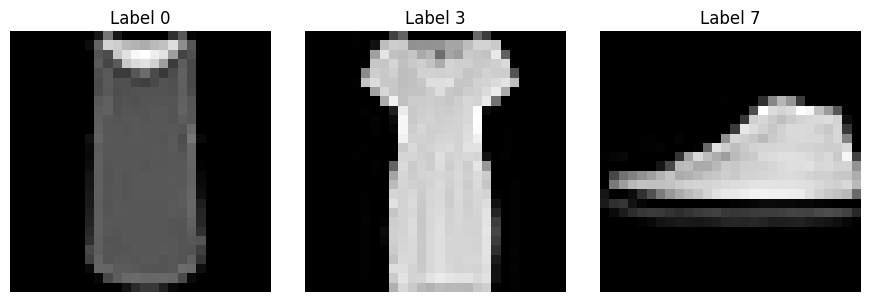

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3))

samples = [
    ('fashion_mnist_images/train/0/0001.png', 'Label 0'),
    ('fashion_mnist_images/train/3/0001.png', 'Label 3'),
    ('fashion_mnist_images/train/7/0002.png', 'Label 7'),
]

for ax, (path, title) in zip(axes, samples):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    ax.imshow(img, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


### Load into `X`, `y` Lists

In [35]:
# Loads a MNIST dataset 
def load_mnist_dataset(dataset, path): 
 
    # Scan all the directories and create a list of labels 
    labels = os.listdir(os.path.join(path, dataset)) 
 
    # Create lists for samples and labels 
    X = [] 
    y = [] 
 
    # For each label folder 
    for label in labels: 
        # And for each image in given folder 
        for file in os.listdir(os.path.join(path, dataset, label)): 
            # Read the image 
            image = cv2.imread(os.path.join( 
                        path, dataset, label, file 
                    ), cv2.IMREAD_UNCHANGED) 
 
            # And append it and a label to the lists 
            X.append(image) 
            y.append(label) 
 
    # Convert the data to proper numpy arrays and return 
    return np.array(X), np.array(y).astype('uint8') 

# MNIST dataset (train + test) 
def create_data_mnist(path): 

    # Load both sets separately 
    X, y = load_mnist_dataset('train', path) 
    X_test, y_test = load_mnist_dataset('test', path) 
 
    # And return all the data 
    return X, y, X_test, y_test 

# Data Preprocessing

Next, we will ​ scale the data (not the images, but the data representing them, the numbers). Neural networks tend to work best with data in the range of either 0 to 1 or -1 to 1. Here, the image data are within the range 0 to 255. 

In [36]:
X, y, X_test, y_test = create_data_mnist('fashion_mnist_images')

X  =  (X.astype(np.float32) -  127.5 )  /  127.5 
X_test  =  (X_test.astype(np.float32) -  127.5 )  /  127.5 

print(X.min(), X.max())
print(f"Shape: {X.shape}")

# We must flatten them into 1D arrays to pass into Dense layers
X_flattened  =  X.reshape(X.shape[0], -1) 
X_test_flattened  =  X_test.reshape(X_test.shape[0], -1) 

print(X_flattened.shape)

-1.0 1.0
Shape: (60000, 28, 28)
(60000, 784)


### Data Shuffling

While we train on the first 6,000 samples, the model will learn that the quickest way to reduce loss is to always predict a 0, since it’ll see several batches of the data with class 0 only. Then, between 6,000 and 12,000, the loss will initially spike as the label will change and the model will be predicting, incorrectly, still label 0, and will likely learn that now it needs to always predict class 1 (as that’s all it sees in batches of labels which we optimize for). The model will cycle local minimums following whichever label is currently being repeated over batches and will most likely never find a global minimum. This process will continue until we get through all samples, repeating however many epochs we selected. 

In [39]:
X, y, X_test, y_test = create_data_mnist('fashion_mnist_images')

keys = np.array(range(X.shape[0]))

print(f"Pre-shuffled keys: {keys}")

np.random.shuffle(keys)
print(f"Post-shuffled keys: {keys}")

# We can apply the shuffed keys with:

X = X[keys]
y = y[keys]


Pre-shuffled keys: [    0     1     2 ... 59997 59998 59999]
Post-shuffled keys: [24795 14312 23692 ... 55516 58753 23693]


# Batches

In [ ]:

X, y = spiral_data(samples=100, classes=3)

epochs = 10
batch_size = 128

# calculate how many steps we need
# for our current dataset
steps = X.shape[0] // batch_size


# // rounds down so if the shape of
# the first batch is greater than
# our current steps * batch size
# increase by one to ensure all data
# is accounted for
if steps * batch_size < X.shape[0]:
    steps += 1

for epoch in range(epochs):
    for step in range(steps):
        batch_X = X[step * batch_size: (step+1) * batch_size]
        batch_y = y[step * batch_size: (step+1) * batch_size]


### Modifying our Loss Class for Batches

In [60]:
# Modified Loss Class
class Loss:
    def remember_trainable_layers(self, trainable_layers):
        self.trainable_layers = trainable_layers

    def regularization_loss(self):
        regularization_loss = 0

        for layer in self.trainable_layers:
            if layer.weight_regularizer_l1 > 0:
                regularization_loss += layer.weight_regularizer_l1 * np.sum(abs(layer.weights))
            if layer.bias_regularizer_l1 > 0:
                regularization_loss += layer.bias_regularizer_l1 * np.sum(abs(layer.biases))
            if layer.weight_regularizer_l2 > 0:
                regularization_loss += layer.weight_regularizer_l2 * np.sum(layer.weights ** 2)
            if layer.bias_regularizer_l2 > 0:
                regularization_loss += layer.bias_regularizer_l2 * np.sum(layer.biases ** 2)
        
        return regularization_loss

    def calculate(self, output, y, include_regularization=False):

        sample_losses = self.forward(output, y)
        data_loss = np.mean(sample_losses)
        
        # add accumulated sum and count
        self.accumulated_sum += np.sum(sample_losses)
        self.accumulated_count += np.sum(len(sample_losses)) 
        
        if not include_regularization:
            return data_loss
        return data_loss, self.regularization_loss()
    
    # add calculated accumulated
    # so at the end of training with batches
    # we can find the accumulated losses
    def calculate_accumulated(self, *, include_regularization=False):
        
        # calculate mean loss
        data_loss = self.accumulated_sum / self.accumulated_count

        if not include_regularization:
            return data_loss
        
        return data_loss, self.regularization_loss()
    
    # reset variables for each new pass
    def new_pass(self):
        self.accumulated_count = 0
        self.accumulated_sum = 0
        

### Modifying our Accuracy Class for Batches

In [65]:
# Modified Accuracy Class
class Accuracy:
    def calculate(self, predictions, y):
        comparisons = self.compare(predictions, y)

        # track accumulations
        self.accumulated_sum += np.sum(comparisons)
        self.accumulated_count += np.sum(len(comparisons))
    
        accuracy = np.mean(comparisons)
        return accuracy
    
    # calculate accumulated method
    def calculate_accumulated(self):

        accuracy = self.accumulated_sum / self.accumulated_count

        return accuracy
    
    # reset on new passes
    def new_pass(self):
        self.accumulated_sum = 0
        self.accumulated_count = 0

### Modifying Model Class for Batches

In [73]:
# Modified Model Class
class Model:
    def __init__(self):
        self.layers = []
        self.softmax_classifier_output = None
    
    def add(self, layer):
        self.layers.append(layer)
    
    def set(self, *, loss, optimizer, accuracy):
        self.loss = loss
        self.optimizer = optimizer
        self.accuracy = accuracy
    
    # Add new batch_size parameter
    def train(self, X, y, *, epochs=1, print_every=1, batch_size = None, validation_data=None):
        self.accuracy.init(y)

        train_steps = 1

        # for batching
        if validation_data is not None:
            validation_steps = 1

            X_val, y_val = validation_data

        # checks if batch used
        if batch_size is not None:
            train_steps += len(X) // batch_size

            if train_steps * batch_size < len(X):
                train_steps += 1
            
            # validation data for batching
            if validation_data is not None:
                validation_steps += len(X_val) // batch_size

                if validation_steps * batch_size < len(X_val):
                    validation_steps += 1

        for epoch in range(1, epochs+1):

            print(f"epoch: {epoch}")

            self.loss.new_pass()
            self.accuracy.new_pass()

            # iteration over steps
            for step in range(train_steps):

                if batch_size:
                    X_batch = X[step * batch_size:(step+1)*batch_size]
                    y_batch = y[step * batch_size:(step+1)*batch_size]
                
                else:
                    X_batch = X
                    y_batch = y
            
                output = self.forward(X_batch, training=True)

                data_loss, regularization_loss = self.loss.calculate(output, y_batch, include_regularization=True)
                loss = data_loss + regularization_loss

                predictions = self.output_layer_activation.predictions(output)
                accuracy = self.accuracy.calculate(predictions, y_batch)

                self.backward(output, y_batch)

                self.optimizer.pre_update_params()
                for trainable_layer in self.trainable_layers:
                    self.optimizer.update_params(trainable_layer)
                self.optimizer.post_update_params()

                if not step % print_every or step == train_steps - 1: 
                    print(f'step: {step}, ' + 
                        f'acc: {accuracy:.3f}, ' + 
                        f'loss: {loss:.3f} (' + 
                        f'data_loss: {data_loss:.3f}, ' + 
                        f'reg_loss: {regularization_loss:.3f}), ' + 
                        f'lr: {self.optimizer.current_learning_rate}')   

            # Get and print epoch loss and accuracy 
            epoch_data_loss, epoch_regularization_loss = self.loss.calculate_accumulated(include_regularization=True) 
            epoch_loss = epoch_data_loss + epoch_regularization_loss 
            epoch_accuracy = self.accuracy.calculate_accumulated() 
 
            print(f'training, ' + 
                  f'acc: {epoch_accuracy:.3f}, ' + 
                  f'loss: {epoch_loss:.3f} (' + 
                  f'data_loss: {epoch_data_loss:.3f}, ' + 
                  f'reg_loss: {epoch_regularization_loss:.3f}), ' + 
                  f'lr: {self.optimizer.current_learning_rate}') 

        if validation_data is not None: 
            # reset values
            self.loss.new_pass()
            self.accuracy.new_pass()

            # validate with batches
            for step in range(validation_steps):

                if batch_size:
                    X_batch = X_val[step*batch_size:(step+1)*batch_size]
                    y_batch = y_val[step*batch_size:(step+1)*batch_size]
                else:
                    X_batch = X_val
                    y_batch = y_val
                
                output = self.forward(X_batch, training=False) 

                loss = self.loss.calculate(output, y_batch) 

                predictions = self.output_layer_activation.predictions(output) 
                accuracy = self.accuracy.calculate(predictions, y_batch) 

            validation_loss = self.loss.calculate_accumulated()
            validation_accuracy = self.accuracy.calculate_accumulated()

            print(f'validation, ' + 
                    f'acc: {validation_accuracy:.3f}, ' + 
                    f'loss: {validation_loss:.3f}')           

    def finalize(self):
        self.input_layer = Layer_Input()

        layer_count = len(self.layers)

        self.trainable_layers = []

        for i in range(layer_count):

            if i == 0:
                self.layers[i].prev = self.input_layer
                self.layers[i].next = self.layers[i+1]
            
            elif i < layer_count - 1:
                self.layers[i].prev = self.layers[i-1]
                self.layers[i].next = self.layers[i+1]
            
            else:
                self.layers[i].prev = self.layers[i-1]
                self.layers[i].next = self.loss
                self.output_layer_activation = self.layers[i]

            if hasattr(self.layers[i], "weights"):
                self.trainable_layers.append(self.layers[i])
            
        self.loss.remember_trainable_layers(self.trainable_layers)

        if isinstance(self.layers[-1], Activation_Softmax) and isinstance(self.loss, Loss_CategoricalCrossentropy): 
            self.softmax_classifier_output = Activation_Softmax_Loss_CategoricalCrossentropy() 
    
    def forward(self, X, training):
        self.input_layer.forward(X, training)

        for layer in self.layers:
            layer.forward(layer.prev.output, training)
        
        return layer.output

    def backward(self, output, y):

        if self.softmax_classifier_output is not None: 
            self.softmax_classifier_output.backward(output, y) 
            self.layers[-1].dinputs = self.softmax_classifier_output.dinputs 

            for layer in reversed(self.layers[:-1]): 
                layer.backward(layer.next.dinputs) 
            return         

        self.loss.backward(output, y)

        for layer in reversed(self.layers):
            layer.backward(layer.next.dinputs)
        

In [67]:
# Init other objects...

class Loss_MeanSquareError(Loss):
    def forward(self, y_pred, y_true):

        sample_losses = np.mean((y_true - y_pred) ** 2, axis=-1)
        return sample_losses
    
    def backward(self, dvalues, y_true):
        samples = len(y_true)

        outputs = len(dvalues[0])

        self.dinputs = -2 * (y_true - dvalues) / outputs
        
        self.dinputs = self.dinputs / samples

class Loss_BinaryCrossEntropy(Loss):
    # Forward pass
    def forward(self, y_pred, y_true):
        # Clip data to prevent divsion by 0
        y_pred_clipped = np.clip(y_pred, 1e-7, 1-1e-7)
        sample_losses = - (y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped))
        
        loss_mean = np.mean(sample_losses, axis=-1)
        return loss_mean

    # Backward pass 
    def backward(self, dvalues, y_true): 
        # Number of samples 
        samples = len(dvalues) 
        # Number of outputs in every sample 
        # We'll use the first sample to count them 
        outputs = len(dvalues[0]) 
 
        # Clip data to prevent division by 0 
        clipped_dvalues = np.clip(dvalues, 1e-7, 1 - 1e-7) 
 
        # Calculate gradient 
        self.dinputs = -(y_true / clipped_dvalues - (1 - y_true) / (1 - clipped_dvalues)) / outputs 
        # Normalize gradient 
        self.dinputs = self.dinputs / samples    

class Loss_CategoricalCrossentropy(Loss): 
    def forward(self, y_pred, y_true): 
        samples = len(y_pred) 
        y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7) 
        if len(y_true.shape) == 1: 
            correct_confidences = y_pred_clipped[ 
                range(samples), 
                y_true 
            ] 
        elif len(y_true.shape) == 2: 
            correct_confidences = np.sum( 
                y_pred_clipped * y_true, 
                axis=1 
            ) 
 
        negative_log_likelihoods = -np.log(correct_confidences) 
        return negative_log_likelihoods 
 
    def backward(self, dvalues, y_true): 
        samples = len(dvalues) 
        labels = len(dvalues[0]) 

        if len(y_true.shape) == 1: 
            y_true = np.eye(labels)[y_true] 
 
        self.dinputs = -y_true / dvalues 
        self.dinputs = self.dinputs / samples 

class Layer_Dense:
    def __init__(self, n_inputs, n_neurons,
                 weight_regularizer_l1=0, bias_regularizer_l1=0,
                 weight_regularizer_l2=0, bias_regularizer_l2=0):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

        # initialize here
        self.weight_regularizer_l1 = weight_regularizer_l1
        self.bias_regularizer_l1 = bias_regularizer_l1
        self.weight_regularizer_l2 = weight_regularizer_l2
        self.bias_regularizer_l2 = bias_regularizer_l2        

    def forward(self, inputs, training):
        self.inputs = inputs 
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues) 
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)         

        # backwards pass
        # integrate l1 regularizer here
        if self.weight_regularizer_l1 > 0:
            dL1 = np.ones_like(self.weights)
            dL1[self.weights < 0] = -1
            self.dweights += self.weight_regularizer_l1 * dL1
        if self.bias_regularizer_l1 > 0:
            dL1 = np.ones_like(self.biases)
            dL1[self.biases < 0] = -1
            self.dbiases += self.bias_regularizer_l1 * dL1

        # integrate l2 regularizer here
        if self.weight_regularizer_l2 > 0:
            self.dweights += 2 * self.weight_regularizer_l2 * self.weights
        if self.bias_regularizer_l2 > 0:
            self.dbiases += 2 * self.bias_regularizer_l2 * self.biases

        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU: 
    def forward(self, inputs, training): 
        self.inputs = inputs 
        self.output = np.maximum(0, inputs) 

    def backward(self, dvalues): 
        self.dinputs = dvalues.copy() 
        self.dinputs[self.inputs <= 0] = 0 
    
    def predictions(self, outputs):
        return outputs # TODO

class Activation_Softmax: 
    def forward(self, inputs, training): 
        self.inputs = inputs 
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) 
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True) 
        self.output = probabilities 

    def backward(self, dvalues): 
        self.dinputs = np.empty_like(dvalues) 
 
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)): 
            single_output = single_output.reshape(-1, 1) 
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T) 

            self.dinputs[index] = np.dot(jacobian_matrix, 
                                         single_dvalues) 
    
    # add prediction
    def predictions(self, outputs):
        return np.argmax(outputs, axis=-1)

class Activation_Sigmoid:
    def forward(self, inputs, training):
        self.inputs = inputs
        self.output = 1 / (1 + np.exp(-inputs))
    
    def backward(self, dvalues):
        self.dinputs = dvalues * (1 - self.output) * self.output

    # add prediction
    def predictions(self, outputs):
        return (outputs > 0.5) * 1

class Activation_Linear:
    def forward(self, inputs, training):
        self.inputs = inputs
        self.output = inputs
    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
    
    # add prediction
    def predictions(self, outputs):
        return outputs

class Optimizer_Adam: 
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7, beta_1=0.9, beta_2=0.999): 
        self.learning_rate = learning_rate 
        self.current_learning_rate = learning_rate 
        self.decay = decay 
        self.iterations = 0 
        self.epsilon = epsilon 
        self.beta_1 = beta_1 
        self.beta_2 = beta_2 
 
    def pre_update_params(self): 
        if self.decay: 
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations)) 
 
    def update_params(self, layer): 
 
        if not hasattr(layer, 'weight_cache'): 
            layer.weight_momentums = np.zeros_like(layer.weights) 
            layer.weight_cache = np.zeros_like(layer.weights) 
            layer.bias_momentums = np.zeros_like(layer.biases) 
            layer.bias_cache = np.zeros_like(layer.biases) 
 
        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1 - self.beta_1) * layer.dweights 
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1 - self.beta_1) * layer.dbiases 

        weight_momentums_corrected = layer.weight_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 
        bias_momentums_corrected = layer.bias_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 

        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights**2 
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1 - self.beta_2) * layer.dbiases**2 

        weight_cache_corrected = layer.weight_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
        bias_cache_corrected = layer.bias_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
 
        layer.weights += -self.current_learning_rate * weight_momentums_corrected / (np.sqrt(weight_cache_corrected) + self.epsilon) 
        layer.biases += -self.current_learning_rate * bias_momentums_corrected / (np.sqrt(bias_cache_corrected) + self.epsilon) 
 
    def post_update_params(self): 
        self.iterations += 1 

class Accuracy_Regression(Accuracy):
    def __init__(self):
        self.precision = None

    def init(self, y, reinit=False):
        if self.precision is None or reinit == True:
            self.precision = np.std(y) / 250

    def compare(self, y_pred, y_true):
        return np.absolute(y_pred - y_true) < self.precision

## Accuracy Categorical

class Accuracy_Categorical(Accuracy):
    def init(self, y, reinit=False):
        pass
    def compare(self, y_pred, y):
        if len(y.shape) == 2:
            y = np.argmax(y, axis=1)
        return y_pred == y

# Softmax classifier - combined Softmax activation 
# and cross-entropy loss for faster backward step 
class Activation_Softmax_Loss_CategoricalCrossentropy(): 
 
    # Backward pass 
    def backward(self, dvalues, y_true): 
 
        # Number of samples 
        samples = len(dvalues) 
 
        # Copy so we can safely modify 
        self.dinputs = dvalues.copy() 
        # Calculate gradient 
        self.dinputs[range(samples), y_true] -= 1 
        # Normalize gradient 
        self.dinputs = self.dinputs / samples 

class Layer_Dropout:
    def __init__(self, rate):
        self.rate = 1- rate
    
    def forward(self, inputs, training):
        self.inputs = inputs

        if not training:
            self.output = self.inputs.copy()
            return self.output
        
        self.binary_mask = np.random.binomial(1, 1-self.rate, self.inputs.shape)
        self.output = self.inputs * self.binary_mask

    def backward(self, dvalues):
        self.dinputs = dvalues * self.binary_mask

class Layer_Input:
    def forward(self, inputs, training):
        self.output = inputs

# Training

In [76]:
X, y, X_test, y_test = create_data_mnist("fashion_mnist_images")

# shuffle data
keys = np.array(range(X.shape[0]))
np.random.shuffle(keys)

X = X[keys]
y = y[keys]

X = (X.reshape(X.shape[0], -1).astype(np.float32) - 127.5) / 127.5
X_test = (X_test.reshape(X_test.shape[0], -1).astype(np.float32) - 127.5) / 127.5

# Instantiate the model 
model  =  Model() 
# Add layers 
model.add(Layer_Dense(X.shape[1],  64)) 
model.add(Activation_ReLU()) 
model.add(Layer_Dense(64,  64)) 
model.add(Activation_ReLU()) 
model.add(Layer_Dense(64,  10)) 
model.add(Activation_Softmax()) 

model.set(loss=Loss_CategoricalCrossentropy(),
          optimizer=Optimizer_Adam(decay=5e-5),
          accuracy=Accuracy_Categorical())

model.finalize()

model.train(X, y, validation_data=(X_test, y_test), batch_size=128, print_every=100, epochs=5)


epoch: 1
step: 0, acc: 0.164, loss: 2.310 (data_loss: 2.310, reg_loss: 0.000), lr: 0.001
step: 100, acc: 0.773, loss: 0.495 (data_loss: 0.495, reg_loss: 0.000), lr: 0.0009950248756218907
step: 200, acc: 0.797, loss: 0.576 (data_loss: 0.576, reg_loss: 0.000), lr: 0.0009900990099009901
step: 300, acc: 0.805, loss: 0.497 (data_loss: 0.497, reg_loss: 0.000), lr: 0.0009852216748768474
step: 400, acc: 0.891, loss: 0.303 (data_loss: 0.303, reg_loss: 0.000), lr: 0.000980392156862745
step: 468, acc: 0.771, loss: 0.532 (data_loss: 0.532, reg_loss: 0.000), lr: 0.0009771350400625367
training, acc: 0.803, loss: 0.549 (data_loss: 0.549, reg_loss: 0.000), lr: 0.0009771350400625367
epoch: 2
step: 0, acc: 0.820, loss: 0.471 (data_loss: 0.471, reg_loss: 0.000), lr: 0.0009770873027505008
step: 100, acc: 0.836, loss: 0.400 (data_loss: 0.400, reg_loss: 0.000), lr: 0.000972337012008362
step: 200, acc: 0.914, loss: 0.439 (data_loss: 0.439, reg_loss: 0.000), lr: 0.0009676326866321544
step: 300, acc: 0.867, lo